In [1]:
# Connect Google Drive to Colab

from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
# Import the libraries needed at the beginning

import pandas as pd
import matplotlib.pyplot as plt
import os

In [3]:
# Location of the cleaned spatial dataset

data_file = "/content/drive/MyDrive/disseration/stage2_outputs/collision_cleaned_spatial.csv"


# Create a separate folder for Stage 4 outputs

stage4_folder = "/content/drive/MyDrive/disseration/stage4_outputs"

os.makedirs(stage4_folder, exist_ok=True)


print("Input file:")
print(data_file)

print("\nOutput folder:")
print(stage4_folder)

Input file:
/content/drive/MyDrive/disseration/stage2_outputs/collision_cleaned_spatial.csv

Output folder:
/content/drive/MyDrive/disseration/stage4_outputs


In [4]:
# Load the cleaned spatial dataset

df = pd.read_csv(
    data_file,
    low_memory=False
)

print("Dataset loaded successfully")

Dataset loaded successfully


In [5]:
# Check the size of the dataset

print("Number of records:", df.shape[0])

print("Number of columns:", df.shape[1])

Number of records: 503410
Number of columns: 63


In [6]:
# Check that latitude and longitude are available

df[
    [
        "longitude",
        "latitude"
    ]
].head()

,longitude,latitude
0,-1.270905,54.689833
1,-1.218333,54.690592
2,-1.232884,54.570397
3,-1.233040,54.520825
4,-1.290292,54.580641


In [7]:
# Confirm that coordinate values are available

print(
    "Missing longitude values:",
    df["longitude"].isna().sum()
)

print(
    "Missing latitude values:",
    df["latitude"].isna().sum()
)

Missing longitude values: 0
Missing latitude values: 0


The minimum and maximum latitude and longitude values are checked briefly.

This is only a quick spatial check to understand the approximate geographical coverage of the collision records. The coordinate cleaning was already completed during Stage 2.

In [8]:
# Check the minimum and maximum coordinate values

df[
    [
        "longitude",
        "latitude"
    ]
].agg(
    [
        "min",
        "max"
    ]
)

,longitude,latitude
min,-7.497375,49.912210
max,1.759829,60.541144


In [9]:
# Print the ranges more clearly

print(
    "Longitude range:",
    round(df["longitude"].min(), 4),
    "to",
    round(df["longitude"].max(), 4)
)

print(
    "Latitude range:",
    round(df["latitude"].min(), 4),
    "to",
    round(df["latitude"].max(), 4)
)

Longitude range: -7.4974 to 1.7598
Latitude range: 49.9122 to 60.5411


GeoPandas is used because a normal pandas DataFrame cannot directly store or analyse geographical geometries.

GeoPandas adds a geometry column and allows spatial operations such as coordinate transformation, spatial joins and grid analysis.

In [10]:
# Import the spatial libraries

import geopandas as gpd

from shapely.geometry import Point

In [11]:
print(
    "GeoPandas version:",
    gpd.__version__
)

GeoPandas version: 1.1.4


Each collision currently has separate longitude and latitude values.

These values are converted into geographical Point objects. Longitude must be entered before latitude when creating the geometries.

In [12]:
# Create point geometry using longitude and latitude

geometry = gpd.points_from_xy(
    df["longitude"],
    df["latitude"]
)

In [13]:
# Look at the first few point geometries

geometry[:5]

<GeometryArray>
[ <POINT (-1.271 54.69)>, <POINT (-1.218 54.691)>,  <POINT (-1.233 54.57)>,
 <POINT (-1.233 54.521)>,  <POINT (-1.29 54.581)>]
Length: 5, dtype: geometry

The pandas DataFrame is now converted into a GeoDataFrame.

The collision coordinates are originally stored as longitude and latitude, so EPSG:4326 is assigned as the original coordinate reference system.

In [14]:
# Convert the normal DataFrame into a GeoDataFrame

collision_gdf = gpd.GeoDataFrame(
    df,
    geometry=geometry,
    crs="EPSG:4326"
)

print("GeoDataFrame created")

GeoDataFrame created


In [15]:
# Check the type of the new dataset

print(
    type(collision_gdf)
)

<class 'geopandas.geodataframe.GeoDataFrame'>


In [16]:
# Check the assigned coordinate reference system

print(
    collision_gdf.crs
)


EPSG:4326


In [17]:
# View some original coordinates and their point geometry

collision_gdf[
    [
        "longitude",
        "latitude",
        "geometry"
    ]
].head()

,longitude,latitude,geometry
0,-1.270905,54.689833,POINT (-1.2709 54.68983)
1,-1.218333,54.690592,POINT (-1.21833 54.69059)
2,-1.232884,54.570397,POINT (-1.23288 54.5704)
3,-1.233040,54.520825,POINT (-1.23304 54.52082)
4,-1.290292,54.580641,POINT (-1.29029 54.58064)


In [18]:
# Check the geometry type

collision_gdf.geometry.geom_type.value_counts()

,count
Point,503410


EPSG:4326 stores locations using longitude and latitude in degrees.

Degrees are suitable for showing locations on global maps. However, they are not suitable for creating equal-sized UK grid cells or directly measuring distances because degrees do not represent a constant physical distance.

The collision GeoDataFrame is therefore reprojected to EPSG:27700, the British National Grid.

EPSG:27700 represents coordinates using metres. This makes it more suitable for later stages involving:

- Grid construction
- Distance calculations
- Grid dimensions
- Spatial aggregation
- Collision density analysis

The British National Grid will therefore be used for the main spatial analysis.

In [19]:
# Reproject the collision data to the British National Grid

collision_gdf_bng = collision_gdf.to_crs(
    "EPSG:27700"
)

print("Reprojection completed")

Reprojection completed


In [20]:
# Check the new coordinate reference system

print(
    collision_gdf_bng.crs
)

EPSG:27700


The original geometry contains longitude and latitude values in degrees.

After reprojection, the geometry contains British National Grid easting and northing values measured in metres.

In [21]:
# Geometry before reprojection

collision_gdf[
    [
        "longitude",
        "latitude",
        "geometry"
    ]
].head()

,longitude,latitude,geometry
0,-1.270905,54.689833,POINT (-1.2709 54.68983)
1,-1.218333,54.690592,POINT (-1.21833 54.69059)
2,-1.232884,54.570397,POINT (-1.23288 54.5704)
3,-1.233040,54.520825,POINT (-1.23304 54.52082)
4,-1.290292,54.580641,POINT (-1.29029 54.58064)


In [22]:
# Geometry after reprojection

collision_gdf_bng[
    [
        "longitude",
        "latitude",
        "geometry"
    ]
].head()

,longitude,latitude,geometry
0,-1.270905,54.689833,POINT (447097.13 532998.207)
1,-1.218333,54.690592,POINT (450485.039 533119.112)
2,-1.232884,54.570397,POINT (449693.06 519734.407)
3,-1.233040,54.520825,POINT (449743.102 514218.387)
4,-1.290292,54.580641,POINT (445970.111 520835.311)


Separate easting and northing columns are created from the projected geometry.

These variables may be useful during Stage 5 when the collision locations are assigned to grid cells.

In [24]:
# Extract the projected coordinates from the geometry

collision_gdf_bng["bng_easting"] = (
    collision_gdf_bng.geometry.x
)

collision_gdf_bng["bng_northing"] = (
    collision_gdf_bng.geometry.y
)

In [25]:
# View the original and projected coordinates

collision_gdf_bng[
    [
        "longitude",
        "latitude",
        "bng_easting",
        "bng_northing"
    ]
].head()

,longitude,latitude,bng_easting,bng_northing
0,-1.270905,54.689833,447097.130258,532998.207453
1,-1.218333,54.690592,450485.039264,533119.112169
2,-1.232884,54.570397,449693.059527,519734.406686
3,-1.233040,54.520825,449743.102027,514218.387112
4,-1.290292,54.580641,445970.110670,520835.310592


A short check is completed after the coordinate transformation to confirm that the number of records and point geometries have remained unchanged.

In [26]:
# Check the projected spatial dataset

print(
    "Number of records:",
    len(collision_gdf_bng)
)

print(
    "Coordinate reference system:",
    collision_gdf_bng.crs
)

print(
    "Geometry column:",
    collision_gdf_bng.geometry.name
)

print(
    "Geometry types:",
    collision_gdf_bng.geometry.geom_type.unique()
)

Number of records: 503410
Coordinate reference system: EPSG:27700
Geometry column: geometry
Geometry types: ['Point']


The total spatial bounds show the geographical extent covered by all collision points.

GeoPandas returns the values in the following order:

1. Minimum easting
2. Minimum northing
3. Maximum easting
4. Maximum northing

In [27]:
# Find the total spatial extent

bounds = collision_gdf_bng.total_bounds

bounds

array([  65948.85625325,   10210.46529654,  655344.99579499,
       1184352.528357  ])

In [28]:
# Store the values separately

min_easting = bounds[0]

min_northing = bounds[1]

max_easting = bounds[2]

max_northing = bounds[3]

In [29]:
# Print the spatial boundaries

print(
    "Minimum easting:",
    round(min_easting, 2)
)

print(
    "Minimum northing:",
    round(min_northing, 2)
)

print(
    "Maximum easting:",
    round(max_easting, 2)
)

print(
    "Maximum northing:",
    round(max_northing, 2)
)

Minimum easting: 65948.86
Minimum northing: 10210.47
Maximum easting: 655345.0
Maximum northing: 1184352.53


The approximate width and height of the complete study extent are calculated using the projected coordinates.

These measurements describe the overall bounding area and should not be interpreted as road travel distances.

In [30]:
# Calculate the total width and height

width_metres = (
    max_easting - min_easting
)

height_metres = (
    max_northing - min_northing
)

In [31]:
# Convert the measurements from metres to kilometres

print(
    "Approximate width:",
    round(width_metres / 1000, 2),
    "km"
)

print(
    "Approximate height:",
    round(height_metres / 1000, 2),
    "km"
)

Approximate width: 589.4 km
Approximate height: 1174.14 km


A final geometry check is carried out before saving the dataset.

Only empty and invalid geometries are checked because coordinate completeness was already examined during Stage 2.

In [33]:
# Count empty geometries

empty_geometries = (
    collision_gdf_bng.geometry.is_empty.sum()
)

print(
    "Empty geometries:",
    empty_geometries
)

Empty geometries: 0


In [34]:
# Count invalid geometries

invalid_geometries = (
    ~collision_gdf_bng.geometry.is_valid
).sum()

print(
    "Invalid geometries:",
    invalid_geometries
)

Invalid geometries: 0


A simple point map is created to visually check the spatial distribution of the collision records.

The purpose of this map is only to confirm that the points appear in reasonable geographical locations.

This is not a hotspot map and no conclusions about significant collision clustering will be made from this visualisation.

A random sample is used because plotting all 503,410 points may make the map difficult to view and may increase processing time.

In [35]:
# Take a reproducible sample for the checking map

collision_sample = collision_gdf_bng.sample(
    n=50000,
    random_state=42
)

print(
    "Points selected for the map:",
    len(collision_sample)
)

Points selected for the map: 50000


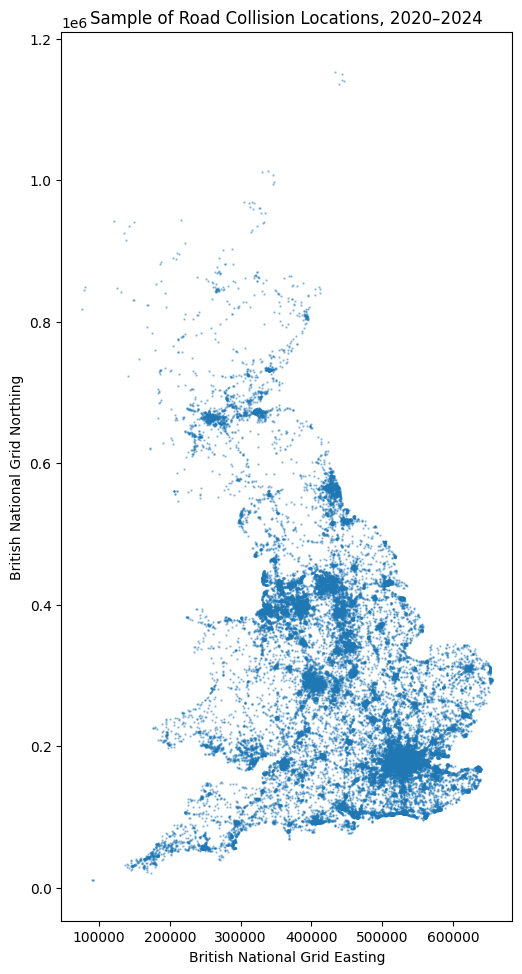

In [36]:
# Create a simple collision point map

fig, ax = plt.subplots(
    figsize=(8, 10)
)

collision_sample.plot(
    ax=ax,
    markersize=0.5,
    alpha=0.4
)

ax.set_title(
    "Sample of Road Collision Locations, 2020–2024"
)

ax.set_xlabel(
    "British National Grid Easting"
)

ax.set_ylabel(
    "British National Grid Northing"
)

plt.tight_layout()

plt.show()

In [37]:
# Set the output location for the map

map_file = os.path.join(
    stage4_folder,
    "collision_point_check_map.png"
)

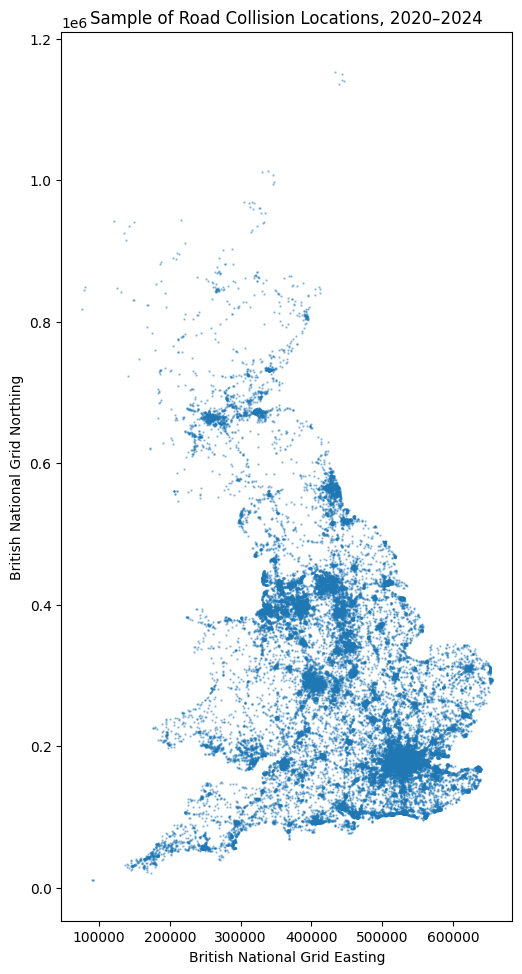

Map saved successfully


In [38]:
# Create the map again and save it

fig, ax = plt.subplots(
    figsize=(8, 10)
)

collision_sample.plot(
    ax=ax,
    markersize=0.5,
    alpha=0.4
)

ax.set_title(
    "Sample of Road Collision Locations, 2020–2024"
)

ax.set_xlabel(
    "British National Grid Easting"
)

ax.set_ylabel(
    "British National Grid Northing"
)

plt.tight_layout()

plt.savefig(
    map_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print("Map saved successfully")

A short summary is created to record the main results of the spatial preparation stage.

The summary contains the number of spatial records, coordinate reference systems, geometry information and spatial boundaries.

In [39]:
# Create a list of the Stage 4 results

summary_data = {

    "measure": [

        "Number of collision records",

        "Missing longitude values",

        "Missing latitude values",

        "Original CRS",

        "Projected CRS",

        "Geometry type",

        "Empty geometries",

        "Invalid geometries",

        "Minimum easting",

        "Minimum northing",

        "Maximum easting",

        "Maximum northing",

        "Approximate width in kilometres",

        "Approximate height in kilometres"
    ],

    "value": [

        len(collision_gdf_bng),

        df["longitude"].isna().sum(),

        df["latitude"].isna().sum(),

        "EPSG:4326",

        "EPSG:27700",

        "Point",

        empty_geometries,

        invalid_geometries,

        round(min_easting, 2),

        round(min_northing, 2),

        round(max_easting, 2),

        round(max_northing, 2),

        round(width_metres / 1000, 2),

        round(height_metres / 1000, 2)
    ]
}

In [40]:
# Convert the summary into a DataFrame

stage4_summary = pd.DataFrame(
    summary_data
)

stage4_summary

,measure,value
0,Number of collision records,503410
1,Missing longitude values,0
2,Missing latitude values,0
3,Original CRS,EPSG:4326
4,Projected CRS,EPSG:27700
5,Geometry type,Point
6,Empty geometries,0
7,Invalid geometries,0
8,Minimum easting,65948.86
9,Minimum northing,10210.47


In [41]:
# Save the summary as a CSV file

summary_file = os.path.join(
    stage4_folder,
    "stage4_spatial_summary.csv"
)

stage4_summary.to_csv(
    summary_file,
    index=False
)

print(
    "Stage 4 summary saved"
)

Stage 4 summary saved


The prepared spatial dataset is saved as a GeoPackage.

A GeoPackage is used because it preserves:

- The collision point geometries
- The EPSG:27700 coordinate reference system
- The cleaned collision attributes

The GeoPackage will be the main spatial input for Stage 5.

In [42]:
# Set the output file location

geopackage_file = os.path.join(
    stage4_folder,
    "collision_spatial_prepared.gpkg"
)

In [43]:
# Save the prepared collision GeoDataFrame

collision_gdf_bng.to_file(
    geopackage_file,
    layer="collision_points",
    driver="GPKG"
)

print(
    "Spatial dataset saved successfully"
)

Spatial dataset saved successfully


A supporting CSV copy is also saved.

The CSV cannot preserve the spatial geometry or coordinate reference system. However, it contains the projected British National Grid easting and northing values and may be useful for checking the data or using selected variables in other software.

In [44]:
# Remove the geometry column before saving as CSV

spatial_csv = collision_gdf_bng.drop(
    columns="geometry"
).copy()

In [45]:
# Set the output location for the CSV

spatial_csv_file = os.path.join(
    stage4_folder,
    "collision_spatial_prepared.csv"
)

In [46]:
# Save the supporting CSV file

spatial_csv.to_csv(
    spatial_csv_file,
    index=False
)

print(
    "Supporting CSV file saved"
)

Supporting CSV file saved


In [47]:
# View the files created during Stage 4

os.listdir(
    stage4_folder
)

['collision_point_check_map.png',
 'stage4_spatial_summary.csv',
 'collision_spatial_prepared.gpkg',
 'collision_spatial_prepared.csv']

The saved GeoPackage is reopened briefly to confirm that the collision records, geometry and coordinate reference system were stored correctly.

In [48]:
# Reopen the saved GeoPackage

saved_gdf = gpd.read_file(
    geopackage_file,
    layer="collision_points"
)

In [49]:
# Check the reopened spatial dataset

print(
    "Saved records:",
    len(saved_gdf)
)

print(
    "Saved CRS:",
    saved_gdf.crs
)

print(
    "Saved geometry type:",
    saved_gdf.geometry.geom_type.unique()
)

Saved records: 503410
Saved CRS: EPSG:27700
Saved geometry type: ['Point']


## Stage 4 Summary

The cleaned spatial collision dataset was loaded using the output created during Stage 2.

A brief coordinate check confirmed that all 503,410 records contained latitude and longitude values.

The pandas DataFrame was converted into a GeoPandas GeoDataFrame by creating Point geometries from longitude and latitude. EPSG:4326 was assigned as the original coordinate reference system because the source coordinates were stored as longitude and latitude.

The collision points were reprojected to EPSG:27700, the British National Grid. This coordinate system represents locations using metres and is more suitable for UK spatial analysis involving grids, distances and spatial aggregation.

British National Grid easting and northing variables were extracted from the projected geometry. The spatial extent and geometry quality were also checked.

A simple point map was created as a visual check of the collision locations. This map was not used for hotspot identification or statistical interpretation.

The prepared collision GeoDataFrame was saved as a GeoPackage for use during Stage 5. A supporting CSV file and Stage 4 spatial summary were also saved.

No grids, hotspot methods, clustering, persistence analysis or modelling were completed during this stage.